# Lab 1: Spatial Transformations (worked solutions)

Companion to `SpatialTransformationsTemplate.ipynb` and `pdfs/Spatial_Transformations.pdf`.

**How to read this notebook.** Every task has the same four parts:

1. **Task:** what the template asks, in one or two lines.
2. **Solution:** the code, ready to run.
3. **How it works:** each piece of syntax and each maths step, line by line.
4. **Example / check:** a small extra cell that shows the syntax on a toy case or verifies the result.

Open the template next to this notebook, compare task by task, and write your own version in the template.
The saved outputs below were produced by running this notebook top to bottom (plots as static images).
When you run it yourself, plots are interactive (`%matplotlib widget`).

**Conventions used everywhere:** angles in radians, NumPy arrays for vectors and matrices, `@` for matrix products.

## Setup

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import os
# alternative 1: SciPy
import scipy
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Slerp
# alternative 2: spatialmath (includes homogeneous transforms)
from spatialmath import SO3, SE3
from spatialmath.base import rotx, rotz, transl, trotx, tr2eul, tr2rpy, tr2angvec, rpy2tr

np.set_printoptions(precision=4, suppress=True)

**How it works**
- `%matplotlib widget` is an IPython *magic* (starts with `%`, only works in Jupyter). It makes plots interactive
  (rotate 3D plots with the mouse). It needs the `ipympl` package.
- `import numpy as np` imports a module under a short alias, so you write `np.array(...)` instead of `numpy.array(...)`.
- `from scipy.spatial.transform import Rotation as R` imports one class from a module and renames it. `R` is SciPy's
  rotation class: it can be built from Euler angles, quaternions, rotation vectors, or matrices and converted between them.
- `from spatialmath.base import rotx, ...` imports plain functions that return NumPy arrays. `SO3`/`SE3` are classes
  (objects with methods) for rotations / rigid transforms.
- `np.set_printoptions(precision=4, suppress=True)` prints 4 decimals and writes tiny numbers such as `6.1e-17` as `0.`.
  It only changes printing, not the stored values. (The template uses `precision=4` only.)

---
## Task 1: Translation along the x- and z-axis
**Task:** define 3×1 column vectors `trvecx` (translation by $a=1$ along x) and `trvecz` (by $d=2$ along z).

In [2]:
a = 1
trvecx = np.array([[a], [0], [0]])
print(trvecx)

d = 2
trvecz = np.array([[0], [0], [d]])
print(trvecz)

[[1]
 [0]
 [0]]
[[0]
 [0]
 [2]]


**How it works**
- `np.array([[a], [0], [0]])`: a list of three one-element lists → a 2D array with 3 rows and 1 column, i.e. a
  **column vector** with shape `(3, 1)`.
- `np.array([a, 0, 0])` (one flat list) would give shape `(3,)`: a 1D array with no row/column orientation.
  Both work for most maths, but mixing them can broadcast in surprising ways (see Task 11). This lab uses `(3, 1)` for
  the 3D vectors because the template asks for column vectors.

**Example: shapes**

In [3]:
print(np.array([1, 0, 0]).shape)          # (3,)   1D array
print(np.array([[1], [0], [0]]).shape)    # (3, 1) column vector
print(np.array([[1, 0, 0]]).shape)        # (1, 3) row vector
print(np.array([1, 0, 0]).reshape(3, 1).shape)   # reshape turns (3,) into (3, 1)

(3,)
(3, 1)
(1, 3)
(3, 1)


---
## Task 2: Rotations about the x- and z-axis
**Task:** rotation matrix `rotmx` for $R_x(\alpha)$, $\alpha=\pi/2$, and `rotmz` for $R_z(\theta)$, $\theta=\pi/4$.

$$
R_x(\alpha)=\begin{bmatrix}1&0&0\\0&\cos\alpha&-\sin\alpha\\0&\sin\alpha&\cos\alpha\end{bmatrix},\qquad
R_z(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}
$$

In [4]:
alpha = np.pi / 2
rotmx = np.array([[1, 0, 0],
                  [0, np.cos(alpha), -np.sin(alpha)],
                  [0, np.sin(alpha),  np.cos(alpha)]])
print(rotmx)

# alternative: spatialmath
rotmx = rotx(alpha)
print(rotmx)

theta = np.pi / 4
rotmz = np.array([[np.cos(theta), -np.sin(theta), 0],
                  [np.sin(theta),  np.cos(theta), 0],
                  [0, 0, 1]])
print(rotmz)

# alternative: spatialmath (used for the rest of the lab)
rotmz = rotz(theta)
print(rotmz)

[[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]
[[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]


**How it works**
- `np.pi`, `np.cos`, `np.sin`: NumPy constants and functions. They work on single numbers and element-wise on arrays.
  Angles are in **radians**.
- The hand-written matrix and `rotx(alpha)` / `rotz(theta)` give the same 3×3 array. `rotx`/`rotz` return plain
  NumPy arrays; `SO3.Rx(alpha)` would return an `SO3` object (get its array with `.A`).
- **Meaning of the columns:** column *i* of a rotation matrix is the *i*-th axis of the rotated frame, written in
  the original frame. For `rotmx`: column 2 is `[0, 0, 1]`, so the new y-axis points along the old z-axis
  (a 90° turn about x).
- A second way (SciPy): `R.from_rotvec([alpha, 0, 0]).as_matrix()`. A rotation vector is axis × angle.

**Check:** every rotation matrix satisfies $R^T R = I$ and $\det R = +1$.

In [5]:
print(np.allclose(rotmx.T @ rotmx, np.eye(3)), np.linalg.det(rotmx))
print(np.allclose(R.from_rotvec([alpha, 0, 0]).as_matrix(), rotmx))    # SciPy gives the same matrix
print(np.allclose(SO3.Rz(theta).A, rotmz))                             # SO3 object -> array with .A

True 1.0
True
True


- `.T` is the transpose, `np.eye(3)` the 3×3 identity, `np.linalg.det` the determinant.
- `np.allclose(A, B)` is `True` if all elements agree up to a small tolerance (safe for floating-point numbers).

---
## Task 3: Composition of rotations
**Task:** `rotmc`: first about x, then about the **current** (rotated) z-axis. `rotmf`: first about x, then about
the **fixed** (original) z-axis.

In [6]:
rotmc = rotmx @ rotmz   # current frame (intrinsic): post-multiply
print(rotmc)

rotmf = rotmz @ rotmx   # fixed frame (extrinsic): pre-multiply
print(rotmf)

[[ 0.7071 -0.7071  0.    ]
 [ 0.      0.     -1.    ]
 [ 0.7071  0.7071  0.    ]]
[[ 0.7071 -0.      0.7071]
 [ 0.7071  0.     -0.7071]
 [ 0.      1.      0.    ]]


**How it works**
- `@` is **matrix multiplication**. `*` would multiply element by element, which is wrong for rotations.
- Rule to remember:
  - rotation about a **current** axis → multiply on the **right** (post-multiply): $R = R_x R_z$
  - rotation about a **fixed** axis → multiply on the **left** (pre-multiply): $R = R_z R_x$
- The two results differ because matrix multiplication is not commutative: the order of rotations matters.

**Example: `@` versus `*`**

In [7]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[0, 1], [1, 0]])
print(A @ B)    # matrix product: swaps the columns of A
print(A * B)    # element-wise product: keeps only the entries where B is 1

[[2 1]
 [4 3]]
[[0 2]
 [3 0]]


---
## Task 4: Apply the rotations to a 3D vector
**Task:** apply `rotmc` and `rotmf` to $p = [1, 2, 0]^T$.

In [8]:
p = np.array([[1], [2], [0]])
pc = rotmc @ p
pf = rotmf @ p
print("pc:")
print(pc)
print("pf:")
print(pf)

pc:
[[-0.7071]
 [ 0.    ]
 [ 2.1213]]
pf:
[[0.7071]
 [0.7071]
 [2.    ]]


**How it works**
- `(3, 3) @ (3, 1)` gives a `(3, 1)` column: the rotated point.
- `pc` and `pf` differ, which again shows that "about the current axis" and "about the fixed axis" are different
  compositions.

---
## Task 5: Rotations and translations on a 3D vector
**Task:** compute $p' = R_x\,(R_z\,(p + t_z) + t_x)$: translate by $d$ along z, rotate by $\theta$ about z,
translate by $a$ along x, rotate by $\alpha$ about x.

In [9]:
ptf = rotmx @ (rotmz @ (p + trvecz) + trvecx)
print(ptf)

[[ 0.2929]
 [-2.    ]
 [ 2.1213]]


**How it works**
- Read from the inside out: `p + trvecz` first, then `rotmz @ ...`, then `+ trvecx`, then `rotmx @ ...`.
  The parentheses make the order explicit.
- `p + trvecz` adds two `(3, 1)` arrays element by element.
- With 3D vectors, a rotation is a multiplication and a translation is an addition, so you have to nest them by hand.
  Homogeneous transforms (next tasks) turn both into one multiplication.

---
## Task 6: Translations as homogeneous transforms
**Task:** 4×4 homogeneous transforms `tformtx` ($H_{tx}$) and `tformtz` ($H_{tz}$) for the two translations.

$$ H = \begin{bmatrix} R & t \\ 0\;0\;0 & 1 \end{bmatrix},\qquad H_{tx} = \begin{bmatrix} I & t_x \\ 0 & 1 \end{bmatrix} $$

In [10]:
tformtx = np.eye(4)
tformtx[:3, 3] = trvecx.flatten()
print(tformtx)

# alternative: spatialmath
tformtx = transl(trvecx.flatten())
print(tformtx)

tformtz = np.eye(4)
tformtz[:3, 3] = trvecz.flatten()
print(tformtz)

tformtz = transl(trvecz.flatten())
print(tformtz)

[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 2.]
 [0. 0. 0. 1.]]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 2.]
 [0. 0. 0. 1.]]


**How it works**
- `np.eye(4)` creates the 4×4 identity matrix (no rotation, no translation).
- `tformtx[:3, 3]` is **slicing**: rows 0, 1, 2 (`:3` means "from the start up to, not including, 3") of column 3.
  That is exactly the translation part of $H$.
- `trvecx.flatten()` turns the `(3, 1)` column into a `(3,)` 1D array so it fits into the 3 slots of that slice.
- `transl([1, 0, 0])` (spatialmath) builds the same pure-translation matrix in one call.
- SciPy has no homogeneous transforms, which is why this lab uses spatialmath for them.

**Example: slicing a 4×4 matrix**

In [11]:
H = np.arange(16).reshape(4, 4)   # the numbers 0..15 arranged in 4 rows
print(H)
print(H[:3, :3])   # top-left 3x3 block: the rotation part
print(H[:3, 3])    # first three entries of the last column: the translation part
print(H[3, :])     # last row: always [0, 0, 0, 1] in a real transform

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]
[[ 0  1  2]
 [ 4  5  6]
 [ 8  9 10]]
[ 3  7 11]
[12 13 14 15]


---
## Task 7: Rotations as homogeneous transforms
**Task:** `tformrotx` ($H_{Rx}$) from `rotmx`, and `tformrotz` ($H_{Rz}$) from `rotmz`.

In [12]:
tformrotx = np.eye(4)
tformrotx[:3, :3] = rotmx
print(tformrotx)

# alternative: spatialmath
tformrotx = trotx(alpha)
print(tformrotx)

tformrotz = np.eye(4)
tformrotz[:3, :3] = rotmz
print(tformrotz)

# alternative: spatialmath
tformrotz = np.array(SE3.Rz(theta))
print(tformrotz)

[[ 1.  0.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  0.  1.]]
[[ 1.  0.  0.  0.]
 [ 0.  0. -1.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  0.  1.]]
[[ 0.7071 -0.7071  0.      0.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]
[[ 0.7071 -0.7071  0.      0.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      1.      0.    ]
 [ 0.      0.      0.      1.    ]]


**How it works**
- `tformrotx[:3, :3] = rotmx` writes the 3×3 rotation into the top-left block; the translation stays zero.
- `trotx(alpha)` returns the 4×4 array directly (the `t` stands for "transform", compare `rotx` which is 3×3).
- `SE3.Rz(theta)` creates an `SE3` object. `np.array(...)` converts it to a plain 4×4 array
  (`SE3.Rz(theta).A` does the same).

---
## Task 8: Composition with respect to the current frame
**Task:** `tformdhc` = translate $d$ along z, rotate $\theta$ about z, translate $a$ along the **new** x, rotate
$\alpha$ about the **new** x, by post-multiplying: $H_{dhc} = H_{tz} H_{Rz} H_{tx} H_{Rx}$.

In [13]:
tformdhc = tformtz @ tformrotz @ tformtx @ tformrotx
print(tformdhc)

[[ 0.7071 -0.      0.7071  0.7071]
 [ 0.7071  0.     -0.7071  0.7071]
 [ 0.      1.      0.      2.    ]
 [ 0.      0.      0.      1.    ]]


**How it works**
- Post-multiplication = every step is taken in the frame produced by the steps before it (current frame).
- This product is exactly the **standard Denavit–Hartenberg link transform**
  $A_i = T_z(d)\,R_z(\theta)\,T_x(a)\,R_x(\alpha)$ with $d=2$, $\theta=\pi/4$, $a=1$, $\alpha=\pi/2$. In Lab 2 each
  of the six myCobot joints gets one such matrix.
- Reading the result: the last column `[0.7071, 0.7071, 2]` is where the new origin sits (2 up, then 1 along the
  x-axis that was turned by 45°). The rotation block is $R_z(\pi/4)R_x(\pi/2)$.

---
## Task 9: Composition with respect to the fixed frame
**Task:** same four steps, but every step about/along the **fixed** axes: $H_{dhf} = H_{Rx} H_{tx} H_{Rz} H_{tz}$.

In [14]:
tformdhf = tformrotx @ tformtx @ tformrotz @ tformtz
print(tformdhf)

[[ 0.7071 -0.7071  0.      1.    ]
 [ 0.      0.     -1.     -2.    ]
 [ 0.7071  0.7071  0.      0.    ]
 [ 0.      0.      0.      1.    ]]


**How it works**
- Fixed-frame steps are pre-multiplied, so the **first** step (translate along z) ends up at the **right** end of
  the product and the last step (rotate about x) at the left.
- `tformdhf` differs from `tformdhc`: same four elementary motions, different reference frames, different result.

---
## Task 10: Homogeneous transform applied to a homogeneous 4D vector
**Task:** $P' = H_{dhf} P$ with $P = [1, 2, 0, 1]^T$.

In [15]:
P = np.append(p, 1)
Ptf = tformdhf @ P
print(P)
print(Ptf)

[1 2 0 1]
[ 0.2929 -2.      2.1213  1.    ]


**How it works**
- A 3D point $p$ becomes the homogeneous vector $P = [p;\,1]$. The trailing 1 is what lets the 4×4 matrix add the
  translation: $H P = [R p + t;\, 1]$.
- `np.append(p, 1)` flattens `p` (shape `(3, 1)`) and appends 1, giving shape `(4,)`.
- `(4, 4) @ (4,)` gives a `(4,)` result; its last entry is 1 again.

---
## Task 11: Compare the 3D and the 4D result
**Task:** the first three entries of $P'$ must equal $p'$ from Task 5.

In [16]:
if np.isclose(ptf.flatten(), Ptf[:3]).all():
    print("ptf and Ptf are equal")
else:
    print("ptf and Ptf are not equal")

ptf and Ptf are equal


**How it works**
- `Ptf[:3]` drops the homogeneous 1. `ptf.flatten()` turns the `(3, 1)` column into `(3,)`, so both have the same
  shape.
- `np.isclose(a, b)` compares element by element **with a tolerance** and returns an array of `True/False`.
  `.all()` is `True` only if every element is `True`.
- Why not `==`? Floating-point results such as `0.7071067811865476` and `0.7071067811865475` differ in the last digit.
- Why they are equal: $H_{Rx}H_{tx}H_{Rz}H_{tz}P$ applied from the right is "add $t_z$, rotate $R_z$, add $t_x$,
  rotate $R_x$", which is exactly Task 5.

**Example: two pitfalls this avoids**

In [17]:
x = 0.1 + 0.2
print(x == 0.3, np.isclose(x, 0.3))          # False True: floating-point rounding

col = np.array([[1.0], [2.0], [3.0]])        # (3, 1)
flat = np.array([1.0, 2.0, 3.0])             # (3,)
print((col == flat).shape)                   # (3, 3)!  broadcasting compares every pair
print(np.isclose(col.flatten(), flat).all()) # True: compare equal shapes

False True
(3, 3)
True


---
## Simplified frame chain (Tasks 12–21)
Robotics Toolbox (`rtb`) builds a chain of frames from **links**. Each link stores the transform from its parent.

In [18]:
import roboticstoolbox as rtb
from roboticstoolbox import ET
from roboticstoolbox.robot.Link import Link

## Task 12: Create a simplified frame chain
**Task:** nothing to code. In Python the chain is built directly from `ET`, `Link` and `rtb.Robot` (Tasks 13–15).

---
## Task 13: Create a joint object
**Task:** `joint1 = ET.SE3(tform)` with the z-translation `tformtz`.

In [19]:
joint1 = ET.SE3(tformtz)
print(joint1)

SE3(0, 0, 2)


**How it works**
- `ET` = *elementary transform*. `ET.SE3(T)` wraps a **constant** 4×4 transform: it has no joint variable, so it is
  a fixed "joint".
- For comparison: `ET.Rz()` without an angle would be a **revolute joint variable** about z, and `ET.tz()` a
  prismatic one. Lab 2's URDF model is a chain of `ET.SE3(...)` (fixed offsets) and `ET.Rz()` (the joints).

---
## Task 14: Create a link object
**Task:** `L1 = Link(joint1, name='b1')`.

In [20]:
L1 = Link(joint1, name='b1')
print(L1)

Link("b1", SE3(0, 0, 2))


**How it works**
- A `Link` is a rigid body plus the transform that places its frame relative to its parent.
- `name='b1'` is a **keyword argument**: you pass it by name, so the order of arguments doesn't matter.

---
## Task 15: Create a link chain
**Task:** list with `L1`, then `frame_chain = rtb.Robot(link_chain)`.

In [21]:
link_chain = [L1]
frame_chain = rtb.Robot(link_chain)

**How it works**
- `[L1]` is a Python list with one element.
- `rtb.Robot(list_of_links)` builds a robot model (a tree of frames) from the links. Here it has 0 joints, only
  fixed transforms.

---
## Task 16: Display the kinematic structure

In [22]:
print(frame_chain)

ERobot: , 0 joints ()
┌──────┬──────┬───────┬────────┬─────────────────────┐
│ link │ link │ joint │ parent │ ETS: parent to link │
├──────┼──────┼───────┼────────┼─────────────────────┤
│    0 │ @b1  │       │ BASE   │ SE3(0, 0, 2)        │
└──────┴──────┴───────┴────────┴─────────────────────┘



**How it works**
- The table lists each link, its joint index (empty = fixed), its parent, and the ETS column
  (elementary transform sequence) from the parent to this link.
- `@` in front of a link name marks an end-effector link (a link without children).

---
## Task 17: Visualize the simplified frame chain
**Task:** `frame_chain.plot(q)` with an empty configuration `q`.

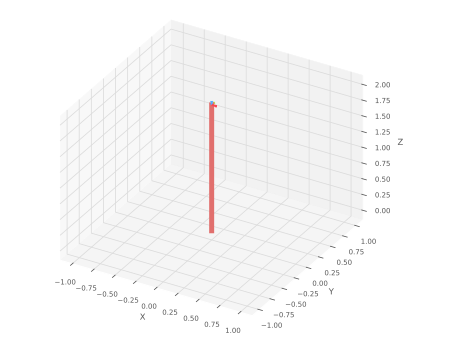

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, '')

In [23]:
q = np.ndarray((1, 0))
frame_chain.plot(q)

**How it works**
- `np.ndarray((1, 0))` creates an array of shape `(1, 0)`: one configuration with zero joint values. It holds no
  numbers, it only has the right shape. `np.zeros((1, 0))` would be the same.
- `.plot(q)` needs a configuration even when nothing moves; with 0 joints the only valid one is empty.
- The plot shows the base frame and frame `b1`, 2 units above it.

---
## Task 18: Configure and attach consecutive links
**Task:** links `L2`, `L3`, `L4` (names `b2`, `b3`, `b4`) with the fixed transforms `tformrotz`, `tformtx`,
`tformrotx`, each link the parent of the next.

In [24]:
joint2 = ET.SE3(tformrotz)
L2 = Link(joint2, name='b2', parent=L1)

joint3 = ET.SE3(tformtx)
L3 = Link(joint3, name='b3', parent=L2)

joint4 = ET.SE3(tformrotx)
L4 = Link(joint4, name='b4', parent=L3)

link_chain = [L1, L2, L3, L4]
frame_chain = rtb.Robot(link_chain)

**How it works**
- `parent=L1` states explicitly that `b2` hangs off `b1`, and so on. (If you leave `parent` out, `rtb.Robot`
  connects the links in list order anyway; giving it makes the tree obvious.)
- The chain order `tz → Rz → tx → Rx` is the same as in Task 8, so the chain reproduces $H_{dhc}$.

---
## Task 19: Display and visualize

ERobot: , 0 joints ()
┌──────┬──────┬───────┬────────┬─────────────────────┐
│ link │ link │ joint │ parent │ ETS: parent to link │
├──────┼──────┼───────┼────────┼─────────────────────┤
│    0 │ b1   │       │ BASE   │ SE3(0, 0, 2)        │
│    1 │ b2   │       │ b1     │ SE3(0°, -0°, 45°)   │
│    2 │ b3   │       │ b2     │ SE3(1, 0, 0)        │
│    3 │ @b4  │       │ b3     │ SE3(90°, -0°, 0°)   │
└──────┴──────┴───────┴────────┴─────────────────────┘



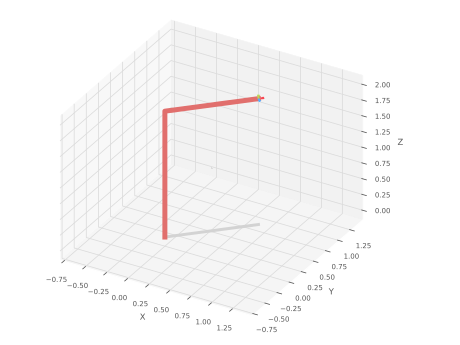

[(-2.0, 2.0), (-2.0, 2.0), (-2.0, 2.0)]

In [25]:
print(frame_chain)
q = np.ndarray((1, 0))
frame_chain_fig = frame_chain.plot(q)
frame_chain_fig.ax.set(xlim=(-2, 2), ylim=(-2, 2), zlim=(-2, 2))

**How it works**
- `.plot(q)` returns a plotting-backend object; its `.ax` attribute is the Matplotlib 3D axes.
- `ax.set(xlim=..., ylim=..., zlim=...)` sets several axis properties in one call. `(-2, 2)` is a **tuple**
  (like a list, but fixed).
- You should see four frames: `b1` 2 up, `b2` turned by 45° about z, `b3` shifted 1 along that turned x, `b4`
  turned 90° about its x.

---
## Task 20: Transformation between two link frames
**Task:** transform from the base to the end frame `b4` with `fkine`.

In [26]:
q = np.ndarray((1, 0))
start_link = frame_chain.base_link
end_link = frame_chain.ee_links[0]

tformdhchain = np.array(frame_chain.fkine(q, start=start_link, end=end_link))
print(tformdhchain)

[[ 0.7071 -0.      0.7071  0.7071]
 [ 0.7071  0.     -0.7071  0.7071]
 [ 0.      1.      0.      2.    ]
 [ 0.      0.      0.      1.    ]]


**How it works**
- `fkine` = *forward kinematics*: multiplies all link transforms from `start` to `end` for the configuration `q`.
- `frame_chain.base_link` is the root link (`b1`, its transform is taken from the world origin);
  `frame_chain.ee_links` is a **list** of end links, `[0]` takes the first (here `b4`).
- `fkine` returns an `SE3` object; `np.array(...)` converts it to a 4×4 array.

---
## Task 21: Compare manual and frame-chain transform

In [27]:
if np.isclose(tformdhc, tformdhchain).all():
    print('tformdhc and tformdhchain are equal')
else:
    print('tformdhc and tformdhchain are not equal')

tformdhc and tformdhchain are equal


**How it works**
- Same comparison pattern as Task 11, now on two 4×4 arrays. They are equal because the chain applies the same four
  transforms in the same (current-frame) order as Task 8.

---
## Task 22: Create a point cloud and visualize it
**Task:** code given. It builds the 12 edges of a small cuboid as a `3 × N` array (row 0 = x, row 1 = y, row 2 = z).

In [28]:
edgelength = 0.2
c = np.arange(0, edgelength + edgelength / 20, edgelength / 20)
p = edgelength * np.ones((len(c)))
# Create sample point cloud data for a small cuboid at the origin.
p = np.concatenate((np.array((0*p, 0*p, c*0.6)), np.array((p, 0*p, c*0.6)), np.array((p, p*0.8, c*0.6)), np.array((0*p, p*0.8, c*0.6)),
                    np.array((0*p, c*0.8, 0*p)), np.array((p, c*0.8, p*0.6)), np.array((0*p, c*0.8, p*0.6)), np.array((p, c*0.8, p*0)),
                    np.array((c, 0*p, 0*p)), np.array((c, p*0.8, 0*p)), np.array((c, 0*p, p*0.6)), np.array((c, p*0.8, p*0.6))), axis=1)
print('point cloud shape:', p.shape)

point cloud shape: (3, 252)


**How it works**
- `np.arange(start, stop, step)` gives evenly spaced numbers from `start` up to (not including) `stop`:
  here 0, 0.01, …, 0.2 (21 values). Adding one step to `stop` makes 0.2 itself part of the range.
- `np.ones(n)` is an array of n ones; `edgelength * np.ones(...)` = n copies of 0.2.
- Each `np.array((xs, ys, zs))` is a `3 × 21` block = one edge. `np.concatenate(..., axis=1)` glues the 12 blocks
  side by side (along the columns), giving `3 × 252`.
- **Note:** this reuses the name `p` (it was the 3D point of Task 4). Re-running Tasks 4–11 after this cell would
  use the point cloud instead. Run the notebook top to bottom.

In [29]:
notebook_path = os.getcwd()
pointcloud_path = os.path.join(notebook_path, 'pointcloud.mat')
if os.path.exists(pointcloud_path):
    data = scipy.io.loadmat(pointcloud_path)
    p = data['p']

- `os.getcwd()` is the folder the notebook runs in; `os.path.join` builds a path with the right separators;
  `os.path.exists` checks for the optional file. Without `pointcloud.mat` this cell does nothing.

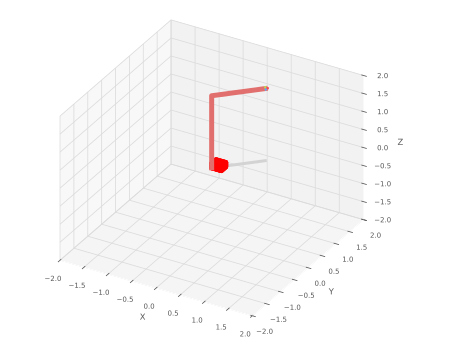

In [30]:
xlim = (-2, 2)
ylim = (-2, 2)
zlim = (-2, 2)
pyplot = rtb.backends.PyPlot.PyPlot()  # create a PyPlot backend
pyplot.launch()
ax = pyplot.ax
# Plot the point cloud in the base frame and overlay it with the chain.
ax.scatter(p[0, :], p[1, :], p[2, :], color='r')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

pyplot.add(frame_chain)
pyplot.step()

- `p[0, :]` is row 0 (all x-coordinates), `p[1, :]` all y, `p[2, :]` all z. `ax.scatter(x, y, z)` draws one dot
  per point.
- `pyplot.add(frame_chain)` draws the robot/frame chain into the same axes; `pyplot.step()` refreshes the drawing.

---
## Task 23: Transform the point cloud into frame `b4`
**Task:** apply `tformdhchain` to all points, using homogeneous 4×N form.

In [31]:
P_h = np.vstack((p, np.ones((1, p.shape[1]))))   # 4 x N homogeneous points
tp = (tformdhchain @ P_h)[:3, :]                  # back to 3 x N
print(P_h.shape, tp.shape)

(4, 252) (3, 252)


**How it works**
- `p.shape[1]` is the number of points N (the number of columns).
- `np.ones((1, N))` is a row of N ones. `np.vstack((p, ones))` stacks it **under** `p` (vertical stack), turning
  every column `[x, y, z]` into `[x, y, z, 1]`.
- One matrix product `(4, 4) @ (4, N)` transforms **all** N points at once: column *k* of the result is
  $H\,P_k$.
- `[:3, :]` keeps the first three rows (drops the row of ones).
- **Meaning:** $H = {}^{base}T_{b4}$ maps coordinates given in frame `b4` to base coordinates. Applying it to the
  cuboid places the cuboid on frame `b4` (blue), while the red one sits at the base. To go the other way (express
  base points in `b4` coordinates) you would use `np.linalg.inv(tformdhchain)`.

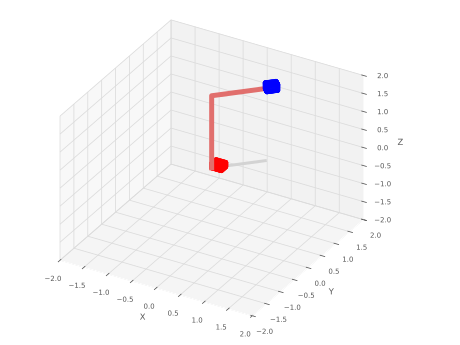

In [32]:
xlim = (-2, 2)
ylim = (-2, 2)
zlim = (-2, 2)
pyplot = rtb.backends.PyPlot.PyPlot()  # create a PyPlot backend
pyplot.launch()
ax = pyplot.ax
# Plot the point cloud in the base frame and overlay it with the chain.
ax.scatter(p[0, :], p[1, :], p[2, :], color='r')
ax.scatter(tp[0, :], tp[1, :], tp[2, :], color='b')  # point cloud attached to the simplified end frame b4

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_zlim(zlim)

pyplot.add(frame_chain)
pyplot.step()

---
## Task 24: Euler angles, roll-pitch-yaw and angle-axis
**Task:** extract the three representations of the rotation in `tformdhchain`.

In [33]:
eul = tr2eul(tformdhchain, flip=True)
print('Euler angles (ZYZ): ' + str(eul))

rpy = tr2rpy(tformdhchain, order='zyx')
print('Roll-pitch-yaw [roll, pitch, yaw]: ' + str(rpy))

axanga = tr2angvec(tformdhchain)
print('Angle-axis (angle, axis): ' + str(axanga))

Euler angles (ZYZ): [ 2.3562 -1.5708 -1.5708]
Roll-pitch-yaw [roll, pitch, yaw]: [ 1.5708 -0.      0.7854]
Angle-axis (angle, axis): (1.7177715174584016, array([0.8629, 0.3574, 0.3574]))


**How it works**
- `tr2eul(T)` returns **ZYZ Euler angles** $[\varphi, \vartheta, \psi]$ with $R = R_z(\varphi)R_y(\vartheta)R_z(\psi)$.
  Every rotation has two ZYZ solutions ($\vartheta$ and $-\vartheta$); `flip=True` picks the one with
  $\vartheta < 0$. Here $[2.356, -1.571, -1.571]$; without `flip` you get the other one, $[-0.785, 1.571, 1.571]$.
- `tr2rpy(T, order='zyx')` returns **`[roll, pitch, yaw]`** with $R = R_z(\text{yaw})R_y(\text{pitch})R_x(\text{roll})$.
  `'zyx'` names the multiplication order, **not** the order of the returned numbers. That is the "manual reordering"
  mentioned in the template: SciPy's `R.from_euler('ZYX', ...)` wants `[yaw, pitch, roll]`, so pass `rpy[::-1]`.
  Here roll = $\pi/2$, pitch = 0, yaw = $\pi/4$: exactly the $R_x(\pi/2)$ and $R_z(\pi/4)$ we built in.
  This is the same convention as `rpy_to_rot` in `helperFunctions.py` and the myCobot controller.
- `tr2angvec(T)` returns a **tuple** `(angle, axis)`: one rotation by `angle` about the unit vector `axis`
  (here 1.718 rad ≈ 98.4° about $[0.863, 0.357, 0.357]$).
- `str(...)` converts a value to text so it can be joined with `+`.

**Check: all three give back the same rotation matrix**

In [34]:
from spatialmath.base import eul2r, rpy2r, angvec2r

Rchain = tformdhchain[:3, :3]
theta_aa, axis_aa = axanga                 # tuple unpacking
print(np.allclose(eul2r(eul), Rchain))
print(np.allclose(rpy2r(rpy, order='zyx'), Rchain))
print(np.allclose(angvec2r(theta_aa, axis_aa), Rchain))
print(np.allclose(R.from_euler('ZYX', rpy[::-1]).as_matrix(), Rchain))   # SciPy needs [yaw, pitch, roll]

True
True
True
True


- `theta_aa, axis_aa = axanga` is **tuple unpacking**: the two elements go into two names.
- `rpy[::-1]` is slicing with step −1: the array reversed.

---
## Tasks 25–26: Animate Euler and roll-pitch-yaw rotations
Rotate by $\varphi=\pi/3$, $\vartheta=\pi/3.5$, $\psi=\pi/4$.

- **ZYZ Euler (Task 25):** $R = R_z(\varphi)\,R_{y'}(\vartheta)\,R_{z''}(\psi)$, each rotation about an axis of the
  **current** (moving) frame. SciPy: uppercase `'ZYZ'` = intrinsic (current axes).
- **RPY (Task 26):** roll $\varphi$ about the **fixed** x, then pitch $\vartheta$ about fixed y, then yaw $\psi$ about
  fixed z. As a matrix $R = R_z(\psi)R_y(\vartheta)R_x(\varphi)$, which SciPy writes as intrinsic
  `'ZYX'` with the arguments reversed: `[psi, theta, phi]`.

Each animation runs in three stages: the first cell animates $\varphi$; the next two cells animate $\vartheta$ and $\psi$
while keeping the earlier angles at their final values. Dashed arrows = original frame, dotted = intermediate frame
at the end of each stage, thin lines = the arcs traced by the axis tips.

*The saved image under each ψ cell shows the end state of the animation (final frame, dotted intermediate frames,
arcs). Run the cells to see the motion.*

## Task 25: Animate the ZYZ Euler rotation

In [35]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from scipy.spatial.transform import Rotation as R
import time

# Initialize the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Set up the axes
ax.set_xlim([-1.25, 1.25])
ax.set_ylim([-1.25, 1.25])
ax.set_zlim([-1.25, 1.25])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True)
ax.view_init(elev=30, azim=140)

# Define the original frame (as column vectors)
O = np.array([0, 0, 0])  # Origin
X0 = np.array([1, 0, 0])  # X-axis vector
Y0 = np.array([0, 1, 0])  # Y-axis vector
Z0 = np.array([0, 0, 1])  # Z-axis vector

# Euler angles
phiF = np.pi / 3
thetaF = np.pi / 3.5
psiF = np.pi / 4
sequence = 'ZYZ'
N = 60   # animation steps per rotation; frame runs 0..N so the last frame reaches the full angle

# Initial plot of the original frame (solid)
quiver_X = ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linewidth=2.5)
quiver_Y = ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linewidth=2.5)
quiver_Z = ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linewidth=2.5)

# Dashed original frame for reference
ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linestyle='dashed', linewidth=2.5)

# Arcs: lists of points traced by the (scaled) axis tips
scale = 0.5
arc = {'X': [scale * X0], 'Y': [scale * Y0], 'Z': [scale * Z0]}
trace_X = ax.plot([scale * X0[0]], [scale * X0[1]], [scale * X0[2]], 'r', linewidth=2)[0]
trace_Y = ax.plot([scale * Y0[0]], [scale * Y0[1]], [scale * Y0[2]], 'g', linewidth=2)[0]
trace_Z = ax.plot([scale * Z0[0]], [scale * Z0[1]], [scale * Z0[2]], 'b', linewidth=2)[0]


def show_frame(rot_matrix, last_frame):
    """Move the solid arrows to the rotated frame, extend the arcs, and on the last
    frame of a stage leave a dotted copy of the intermediate frame behind."""
    X_rot = rot_matrix @ X0
    Y_rot = rot_matrix @ Y0
    Z_rot = rot_matrix @ Z0

    quiver_X.set_segments([[[0, 0, 0], X_rot]])
    quiver_Y.set_segments([[[0, 0, 0], Y_rot]])
    quiver_Z.set_segments([[[0, 0, 0], Z_rot]])

    for key, vec, line in (('X', X_rot, trace_X), ('Y', Y_rot, trace_Y), ('Z', Z_rot, trace_Z)):
        arc[key].append(scale * vec)
        pts = np.array(arc[key])
        line.set_data(pts[:, 0], pts[:, 1])
        line.set_3d_properties(pts[:, 2])

    if last_frame:
        for vec, col in ((X_rot, 'r'), (Y_rot, 'g'), (Z_rot, 'b')):
            ax.quiver(0, 0, 0, vec[0], vec[1], vec[2], color=col, linestyle='dotted', linewidth=1.5)

    return quiver_X, quiver_Y, quiver_Z, trace_X, trace_Y, trace_Z


# Update function for the animation
def update_phi(frame):
    phi = phiF * frame / N  # First rotation about Z (phi)
    theta = 0
    psi = 0
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

# Animation for theta: phi already at its final value
def update_theta(frame):
    phi = phiF
    theta = thetaF * frame / N  # Second rotation about the current Y' (theta)
    psi = 0
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

# Animation for psi: phi and theta at their final values
def update_psi(frame):
    phi = phiF
    theta = thetaF
    psi = psiF * frame / N  # Third rotation about the current Z'' (psi)
    rot_matrix = R.from_euler(sequence, [phi, theta, psi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

# Animate first rotation (phi)
ani_phi = FuncAnimation(fig, update_phi, frames=N + 1, interval=50, blit=False, repeat=False)

**How it works**
- `FuncAnimation(fig, func, frames=N+1, interval=50, blit=False, repeat=False)` calls `func(frame)` for
  `frame = 0, 1, …, N` every 50 ms. `repeat=False` plays it once; `blit=False` redraws the whole figure (simpler and
  needed for 3D). Keep the returned object in a variable (`ani_phi`): if it is garbage-collected the animation stops.
- The template used `frames=60` with `frame / 60`, so the last frame reaches only 59/60 of the angle. With
  `frames=N+1` and `frame / N` the final frame shows the full angle.
- `R.from_euler('ZYZ', [phi, theta, psi]).as_matrix()`: uppercase letters = **intrinsic** rotations (about the moving
  axes); lowercase `'zyz'` would be extrinsic (fixed axes).
- `quiver.set_segments([[[0,0,0], tip]])` moves an existing 3D arrow instead of drawing a new one.
- `line.set_data(xs, ys)` + `line.set_3d_properties(zs)` update a 3D line; together with the `arc` lists this draws
  the arcs of rotation.
- `show_frame` is shared by all three update functions, so each stage differs only in which angle is growing.
- `for key, vec, line in ((...), (...)):` loops over a tuple of tuples and unpacks each into three names.
- `frame == N` is `True` only on the last frame, which is when the dotted intermediate frame is drawn.

In [36]:
ani_theta = FuncAnimation(fig, update_theta, frames=N + 1, interval=50, blit=False, repeat=False)
plt.draw()

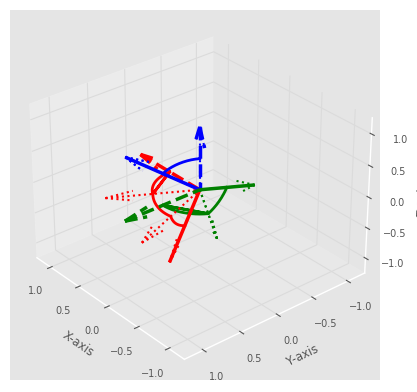

In [37]:
ani_psi = FuncAnimation(fig, update_psi, frames=N + 1, interval=50, blit=False, repeat=False)
plt.draw()

Run these two cells one after the other, each after the previous animation has finished (about 3 s).
`plt.draw()` asks Matplotlib to redraw the figure.

**Check:** the final frame of the three stages is the full ZYZ rotation, which also equals the product of the three
elementary rotations about the current axes:

In [38]:
R_zyz = R.from_euler('ZYZ', [phiF, thetaF, psiF]).as_matrix()
from spatialmath.base import roty
print(np.allclose(R_zyz, rotz(phiF) @ roty(thetaF) @ rotz(psiF)))   # post-multiplication = current axes

True


---
## Task 26: Animate the roll-pitch-yaw rotation

In [39]:
# Initialize the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Set up the axes
ax.set_xlim([-1.25, 1.25])
ax.set_ylim([-1.25, 1.25])
ax.set_zlim([-1.25, 1.25])
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.grid(True)
ax.view_init(elev=30, azim=140)

# RPY angles: roll phi (about fixed x), pitch theta (about fixed y), yaw psi (about fixed z)
phiF = np.pi / 3
thetaF = np.pi / 3.5
psiF = np.pi / 4
sequence = 'ZYX'   # intrinsic ZYX with reversed arguments = extrinsic xyz

# Solid (moving) frame and dashed original frame
quiver_X = ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linewidth=2.5)
quiver_Y = ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linewidth=2.5)
quiver_Z = ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], X0[0], X0[1], X0[2], color='r', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Y0[0], Y0[1], Y0[2], color='g', linestyle='dashed', linewidth=2.5)
ax.quiver(O[0], O[1], O[2], Z0[0], Z0[1], Z0[2], color='b', linestyle='dashed', linewidth=2.5)

arc = {'X': [scale * X0], 'Y': [scale * Y0], 'Z': [scale * Z0]}
trace_X = ax.plot([scale * X0[0]], [scale * X0[1]], [scale * X0[2]], 'r', linewidth=2)[0]
trace_Y = ax.plot([scale * Y0[0]], [scale * Y0[1]], [scale * Y0[2]], 'g', linewidth=2)[0]
trace_Z = ax.plot([scale * Z0[0]], [scale * Z0[1]], [scale * Z0[2]], 'b', linewidth=2)[0]

# show_frame() from Task 25 is reused: it looks up quiver_X, arc, trace_X, ax ... at call time,
# so it now draws into this new figure.

def update_phi(frame):
    phi = phiF * frame / N   # 1st: roll about the fixed x-axis
    theta = 0
    psi = 0
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

def update_theta(frame):
    phi = phiF
    theta = thetaF * frame / N   # 2nd: pitch about the fixed y-axis
    psi = 0
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

def update_psi(frame):
    phi = phiF
    theta = thetaF
    psi = psiF * frame / N   # 3rd: yaw about the fixed z-axis
    rot_matrix = R.from_euler(sequence, [psi, theta, phi]).as_matrix()
    return show_frame(rot_matrix, frame == N)

# Animate first rotation (phi)
ani_phi = FuncAnimation(fig, update_phi, frames=N + 1, interval=50, blit=False, repeat=False)

**How it works**
- Only the rotation changes compared with Task 25: `R.from_euler('ZYX', [psi, theta, phi])`
  $= R_z(\psi)R_y(\vartheta)R_x(\varphi)$. Read right to left, $R_x(\varphi)$ acts first: roll about the fixed x, then
  pitch about the fixed y, then yaw about the fixed z.
- `show_frame` is defined in Task 25. Python functions look up global names (`quiver_X`, `ax`, `arc`, …) when they
  run, not when they are defined, so after this cell rebinds those names the same function draws into the new figure.
- **Cell order:** the template had the ψ cell before the ϑ cell. Run ϑ (pitch) before ψ (yaw), as below:
  `update_theta` keeps ψ = 0 and `update_psi` keeps ϑ at its final value, so the other order would make the frame jump.

In [40]:
ani_theta = FuncAnimation(fig, update_theta, frames=N + 1, interval=50, blit=False, repeat=False)
plt.draw()

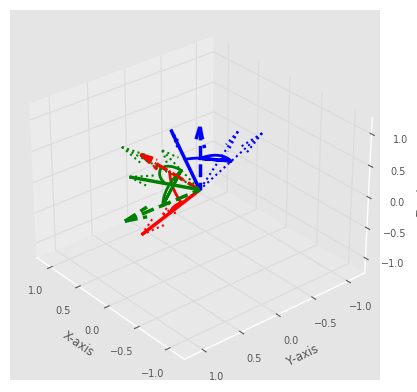

In [41]:
ani_psi = FuncAnimation(fig, update_psi, frames=N + 1, interval=50, blit=False, repeat=False)
plt.draw()

**Check:** intrinsic `'ZYX'` with `[ψ, ϑ, φ]` is the same rotation as extrinsic `'xyz'` with `[φ, ϑ, ψ]`, and the same
as spatialmath's `rpy2r([roll, pitch, yaw])`:

In [42]:
R1 = R.from_euler('ZYX', [psiF, thetaF, phiF]).as_matrix()
R2 = R.from_euler('xyz', [phiF, thetaF, psiF]).as_matrix()
print(np.allclose(R1, R2), np.allclose(R1, rpy2tr(phiF, thetaF, psiF)[:3, :3]))

True True


---
## Representation singularities (Tasks 27–28)
Roll, pitch, yaw: $\alpha=\pi/4$, $\beta=\pi/2$, $\gamma=\pi/4$.

## Task 27: Compose a rotation matrix

In [43]:
alpha_rpy, beta_rpy, gamma_rpy = np.pi / 4, np.pi / 2, np.pi / 4
rotmrpy = rpy2tr(alpha_rpy, beta_rpy, gamma_rpy)[:3, :3]
print(rotmrpy)

[[ 0.  0.  1.]
 [ 0.  1.  0.]
 [-1.  0.  0.]]


**How it works**
- `a, b, c = 1, 2, 3` assigns several names in one line (tuple unpacking again). New names are used so that
  `alpha` from Task 2 is not overwritten.
- `rpy2tr(roll, pitch, yaw)` gives the 4×4 transform of $R_z(\gamma)R_y(\beta)R_x(\alpha)$; `[:3, :3]` keeps the
  rotation block.
- The result is exactly $R_y(\pi/2)$: the roll and the yaw cancelled each other. That is the singularity.

---
## Task 28: Back to roll, pitch, yaw

In [44]:
alphabetagamma = tr2rpy(rotmrpy)
print(alphabetagamma, '(original:', [alpha_rpy, beta_rpy, gamma_rpy], ')')
print('same matrix again?', np.allclose(rpy2tr(*alphabetagamma)[:3, :3], rotmrpy))

[ 0.      1.5708 -0.    ] (original: [0.7853981633974483, 1.5707963267948966, 0.7853981633974483] )
same matrix again? True


**How it works / answer**
- We get `[0, π/2, 0]` instead of `[π/4, π/2, π/4]`, yet it gives the **same** matrix: the angles are not unique.
- **Why:** with pitch $\beta = \pi/2$ the first rotation axis (x, roll) is turned onto the last one (z, yaw).
  Roll and yaw then turn about the same physical axis, so only their difference $\gamma - \alpha$ is determined
  (here 0). This is **gimbal lock**: the three angles lose one degree of freedom. The conversion algorithm
  resolves it by a convention (roll = 0).
- `rpy2tr(*alphabetagamma)`: the `*` **unpacks** an array/list into separate arguments,
  i.e. `rpy2tr(a[0], a[1], a[2])`.

**Example: many roll/yaw pairs, one matrix**

In [45]:
for a_, g_ in [(0, 0), (np.pi/4, np.pi/4), (np.pi/3, np.pi/3), (0.1, 0.1 + 0.5)]:
    Rm = rpy2tr(a_, np.pi / 2, g_)[:3, :3]
    print(f'roll={a_:.3f}, yaw={g_:.3f}, yaw-roll={g_ - a_:.3f} -> equals R_y(pi/2): {np.allclose(Rm, rotmrpy)}')

# SciPy even warns about it:
print(R.from_matrix(rotmrpy).as_euler('xyz'))

roll=0.000, yaw=0.000, yaw-roll=0.000 -> equals R_y(pi/2): True
roll=0.785, yaw=0.785, yaw-roll=0.000 -> equals R_y(pi/2): True
roll=1.047, yaw=1.047, yaw-roll=0.000 -> equals R_y(pi/2): True
roll=0.100, yaw=0.600, yaw-roll=0.500 -> equals R_y(pi/2): False
[-0.      1.5708  0.    ]


/tmp/ipykernel_61821/2295347860.py:6: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  print(R.from_matrix(rotmrpy).as_euler('xyz'))


- `f'...{value:.3f}...'` is an **f-string**: expressions in `{}` are inserted; `:.3f` formats with 3 decimals.
- Only the last pair (different yaw−roll) gives a different matrix. For the myCobot this matters when you command
  a tool orientation with pitch near ±90°: tiny changes in the orientation can make roll and yaw jump.

---
## Quaternion SLERP (Tasks 29–33)
Reference (given): interpolating the **Euler angles** linearly from $[\pi/3, -\pi/2, 0]$ to
$[-\pi/3, \pi/2 + \pi/20, 0]$ (ZYX) and rotating $p = [1, 0, 0]$.

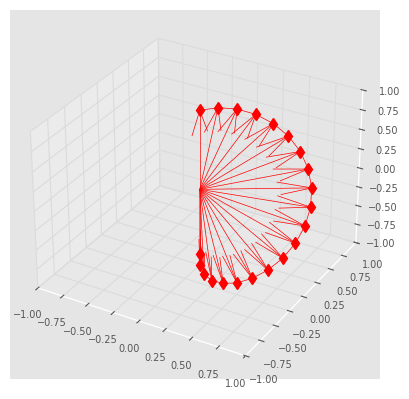

In [46]:
path = np.arange(0, 1.05, 0.05)
p = np.array([1, 0, 0])

euler_angles = np.array([[np.pi/3, -np.pi/2, 0]]) + \
               np.vstack((-path*2*np.pi/3, path*np.pi*1.05, path*0)).T
interpolated_euler = R.from_euler('ZYX', euler_angles).as_matrix()

rPeul = np.zeros((21, 3))
for i in range(21):
    rPeul[i, :] = np.dot(interpolated_euler[i, :, :], p)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(rPeul[:, 0], rPeul[:, 1], rPeul[:, 2], 'r-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rPeul[:, 0], rPeul[:, 1], rPeul[:, 2], color='r')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()

**How it works**
- `np.vstack((a, b, c)).T` stacks three rows and transposes: a `21 × 3` array, one Euler-angle triple per row.
  Adding the `1 × 3` start row uses **broadcasting**: the single row is added to all 21 rows.
- `R.from_euler(..., array_of_triples)` creates 21 rotations at once; `.as_matrix()` has shape `(21, 3, 3)`.
- `np.dot(M, p)` = `M @ p`.
- The red path is **not** the shortest way between the two orientations: Euler angles do not interpolate evenly.

---
## Task 29: ZYX Euler angles to quaternions

In [47]:
q0 = R.from_euler('ZYX', [np.pi/3, -np.pi/2, 0], degrees=False)
q1 = R.from_euler('ZYX', [-np.pi/3, np.pi/2 + np.pi/20, 0], degrees=False)
print('q0 [x, y, z, w]:', q0.as_quat())
print('q1 [x, y, z, w]:', q1.as_quat())

q0 [x, y, z, w]: [ 0.3536 -0.6124  0.3536  0.6124]
q1 [x, y, z, w]: [ 0.3802  0.6585 -0.3247  0.5624]


**How it works**
- A SciPy `Rotation` stores the orientation internally as a unit quaternion. `.as_quat()` shows it in SciPy's order
  **`[x, y, z, w]`** (scalar part last; some books and spatialmath put it first: $[\eta, \epsilon_x, \epsilon_y, \epsilon_z]$).
- `degrees=False` (default) means the angles are radians.

---
## Task 30: SLERP interpolation
**Task:** quaternion SLERP from `q0` to `q1` in steps of 0.05.

In [48]:
key_rots = R.concatenate([q0, q1])
key_times = [0, 1]
slerp = Slerp(key_times, key_rots)
times = np.linspace(0, 1, 21)          # 0, 0.05, ..., 1.0
interp_rots = slerp(times)
print(len(interp_rots), 'interpolated rotations')

21 interpolated rotations


**How it works**
- `R.concatenate([q0, q1])` puts two rotations into one `Rotation` object holding 2 rotations (the "key frames").
- `Slerp(key_times, key_rots)` builds the interpolator: `q0` at time 0, `q1` at time 1.
- `slerp(times)` evaluates it (the object is **callable**, like a function) and returns 21 rotations.
- SLERP = *spherical linear interpolation*: it rotates at constant angular speed about **one fixed axis**, i.e. along
  the shortest great-circle arc between the two orientations.
- `np.linspace(0, 1, 21)` gives exactly 21 points including both ends. `np.arange(0, 1.05, 0.05)` also works here,
  but `arange` with float steps can end slightly above 1.0 due to rounding, and `Slerp` rejects times outside
  `[0, 1]`. `linspace` avoids that risk.

---
## Task 31: Apply the interpolated quaternions to a vector

In [49]:
p = [1, 0, 0]
rP = interp_rots.apply(p)
print(rP.shape)

(21, 3)


- `Rotation.apply(v)` rotates the vector by every rotation in the object: 21 rotated copies, shape `(21, 3)`.

---
## Task 32: Visualize the SLERP path

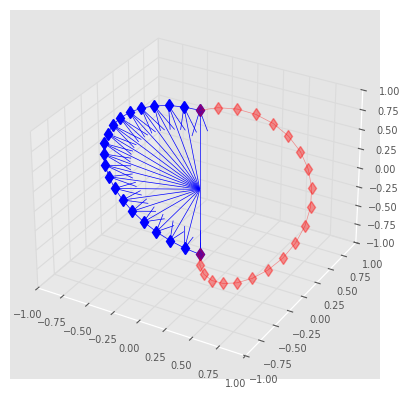

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(rP[:, 0], rP[:, 1], rP[:, 2], 'b-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rP[:, 0], rP[:, 1], rP[:, 2], color='b')
ax.plot3D(rPeul[:, 0], rPeul[:, 1], rPeul[:, 2], 'r-d', alpha=0.4)   # Euler path for comparison
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
plt.show()

**How it works / comparison**
- `'b-d'` is a Matplotlib format string: blue (`b`), solid line (`-`), diamond markers (`d`).
  `alpha=0.4` makes the Euler path transparent.
- **Blue (SLERP):** evenly spaced points on one great-circle arc from the north pole ($z=+1$, where `q0` sends
  $p$) to near the south pole: the shortest path with constant speed.
- **Red (Euler):** uneven spacing and a detour. Interpolating the three angles separately does not give a uniform
  rotation.

---
## Task 33: Remove the offset
**Task:** final orientation $[-\pi/3, \pi/2, 0]$ instead of $[-\pi/3, \pi/2 + \pi/20, 0]$. What happens to the arc?

In [51]:
q2 = R.from_euler('ZYX', [-np.pi/3, np.pi/2, 0])
key_rots = R.concatenate([q0, q2])
key_times = [0, 1]
slerp = Slerp(key_times, key_rots)
times = np.linspace(0, 1, 21)
interp_rots = slerp(times)

p = [1, 0, 0]
rP = interp_rots.apply(p)

ax.plot3D(rP[:, 0], rP[:, 1], rP[:, 2], 'r-d')
ax.quiver(np.zeros(21), np.zeros(21), np.zeros(21),
          rP[:, 0], rP[:, 1], rP[:, 2], color='r')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)

plt.show()

This cell draws into the axes `ax` of Task 32, so with the widget backend both arcs appear in that figure.
In the saved (static) version that figure was already rendered, so the next cell draws both arcs again in a new
figure.

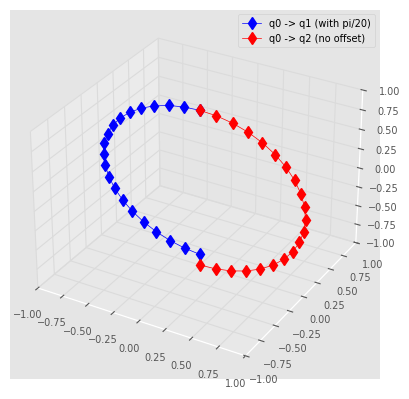

rotation angle q0 -> q1: 175.5 deg
rotation angle q0 -> q2: 180.0 deg
midpoint of blue arc: [-0.9969  0.0652  0.0437]   midpoint of red arc: [ 1.  0. -0.]


In [52]:
rP_q1 = Slerp([0, 1], R.concatenate([q0, q1]))(times).apply([1, 0, 0])
rP_q2 = rP

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(rP_q1[:, 0], rP_q1[:, 1], rP_q1[:, 2], 'b-d', label='q0 -> q1 (with pi/20)')
ax.plot3D(rP_q2[:, 0], rP_q2[:, 1], rP_q2[:, 2], 'r-d', label='q0 -> q2 (no offset)')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
ax.legend()
plt.show()

print('rotation angle q0 -> q1: %.1f deg' % np.degrees((q0.inv() * q1).magnitude()))
print('rotation angle q0 -> q2: %.1f deg' % np.degrees((q0.inv() * q2).magnitude()))
print('midpoint of blue arc:', rP_q1[10], '  midpoint of red arc:', rP_q2[10])

**How it works / answer**
- `q0.inv() * q2` is the rotation that takes `q0` to `q2` (`*` composes SciPy rotations). `.magnitude()` is its
  angle.
- With the offset the relative rotation is **175.5°**, so there is one clearly shortest way round, and SLERP takes it
  (blue arc, passing $x \approx -1$).
- Without the offset the relative rotation is **exactly 180°**. Both ways round are equally long; SLERP has to pick
  one by convention (the sign of the quaternion), and here it picks the **opposite great-circle arc** (red, passing
  $x = +1$).
- Lesson: SLERP always takes the shortest arc. Near a 180° difference, a tiny change of the target can flip the
  direction of the whole motion. For a robot tool this means the wrist may swing the "other way" if the goal
  orientation is almost opposite to the start.
- `'%.1f' % value` is the older printf-style string formatting; it does the same as `f'{value:.1f}'`.

---
## Summary
| Representation | Parameters | Compose | Unique? | Singularities |
|---|---|---|---|---|
| Rotation matrix | 9 numbers (3 free) | `@` | yes | none |
| Homogeneous transform | 4×4, rotation + translation | `@` | yes | none |
| ZYZ Euler / RPY | 3 angles | convert first | no (2 solutions, and ∞ at the singularity) | yes (gimbal lock) |
| Angle-axis | angle + unit axis | convert first | no (−axis, −angle) | angle = 0 (axis undefined) |
| Unit quaternion | 4 numbers | multiply | no (q and −q) | none; best for interpolation (SLERP) |

Current frame → post-multiply. Fixed frame → pre-multiply.